In [1]:
%%capture
## [TEMPLATE BEGIN]
## おまじない：実行中のノートブック名からOUTPUT_DIRを決めるコード
from pathlib import Path
from IPython import get_ipython; ip = get_ipython()
if '__vsc_ipynb_file__' in ip.user_ns:
    ## VS Codeで実行されている場合
    THIS_NOTEBOOK_PATH = Path(ip.user_ns['__vsc_ipynb_file__'])
else:
    !pip install ipynbname
    import ipynbname; THIS_NOTEBOOK_PATH = Path(ipynbname.path())
    if "%2F" in THIS_NOTEBOOK_PATH.stem:
        ## Google Colabで実行されている場合
        colab_ip = %system hostname -I   # uses colab magic to get list from bash
        colab_ip = colab_ip[0].strip()   # returns "172.28.0.12"
        colab_port = 9000                # could use 6000, 8080, or 9000
        import requests
        filename = requests.get(f"http://{colab_ip}:{colab_port}/api/sessions").json()[0]["name"]
        THIS_NOTEBOOK_PATH = Path(filename)
    else:
        ## それ以外の場合
        THIS_NOTEBOOK_PATH = THIS_NOTEBOOK_PATH

OUTPUT_DIR = Path("figures") / THIS_NOTEBOOK_PATH.stem
## [TEMPLATE END]

In [18]:
print("File output directory:", OUTPUT_DIR)
# Create the output directory if it does not exist
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

File output directory: figures/_clustering_toy_data


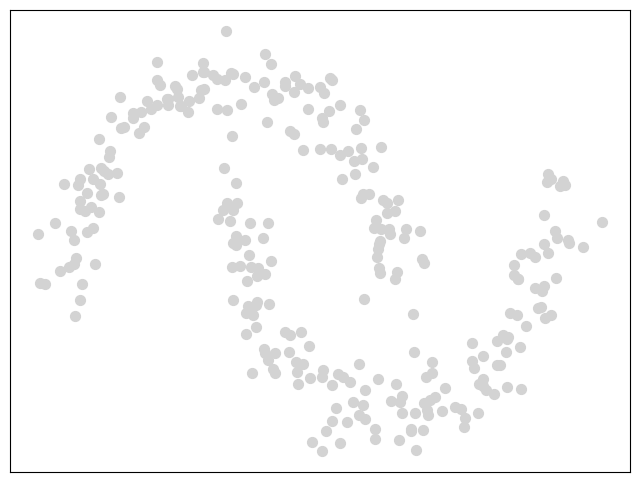

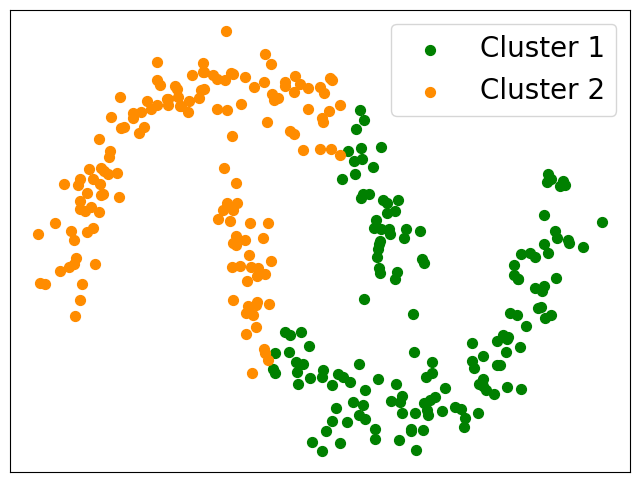

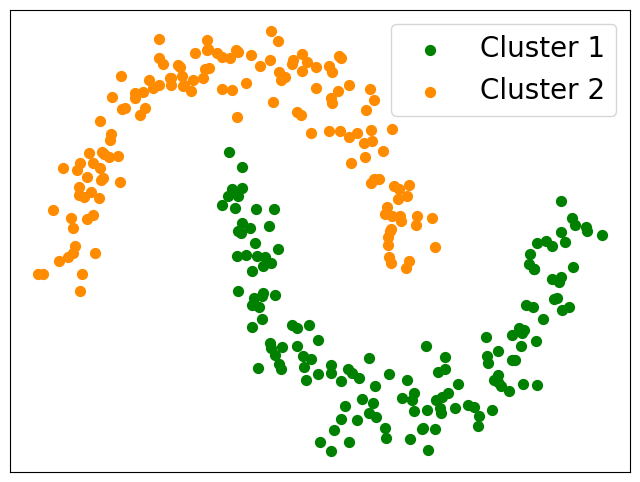

In [19]:
# 必要なライブラリをインポート
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.cluster import KMeans, DBSCAN

# Two-moonデータを生成
X, y = make_moons(n_samples=300, noise=0.1, random_state=0)

# 初期のデータセットの散布図を作成
plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], color='#D3D3D3', s=50)
plt.xticks([])
plt.yticks([])
plt.grid(True)

# 初期データの散布図を保存
output_file_initial = OUTPUT_DIR / "two_moon_initial.png"
plt.savefig(output_file_initial, bbox_inches='tight', pad_inches=0)
plt.show()

# クラスタリングを実行（KMeansを使用）
kmeans = KMeans(n_clusters=2, random_state=0)
y_kmeans = kmeans.fit_predict(X)

# KMeansクラスタリング結果の散布図を作成
plt.figure(figsize=(8, 6))
plt.scatter(X[y_kmeans == 0, 0], X[y_kmeans == 0, 1], color='#008000', s=50, label='Cluster 1')  # グリーン
plt.scatter(X[y_kmeans == 1, 0], X[y_kmeans == 1, 1], color='#FF8C00', s=50, label='Cluster 2')  # ダークオレンジ
plt.xticks([])
plt.yticks([])
plt.legend(fontsize=20)
plt.grid(True)

# KMeansクラスタリング結果の散布図を保存
output_file_clustered_kmeans = OUTPUT_DIR / "two_moon_clustered_failed.png"
plt.savefig(output_file_clustered_kmeans, bbox_inches='tight', pad_inches=0)
plt.show()

# クラスタリングを実行（DBSCANを使用）
dbscan = DBSCAN(eps=0.15, min_samples=5)
y_dbscan = dbscan.fit_predict(X)

# DBSCANクラスタリング結果の散布図を作成
plt.figure(figsize=(8, 6))
plt.scatter(X[y_dbscan == 0, 0], X[y_dbscan == 0, 1], color='#008000', s=50, label='Cluster 1')  # グリーン
plt.scatter(X[y_dbscan == 1, 0], X[y_dbscan == 1, 1], color='#FF8C00', s=50, label='Cluster 2')  # ダークオレンジ
plt.xticks([])
plt.yticks([])
plt.legend(fontsize=20)
plt.grid(True)

# DBSCANクラスタリング結果の散布図を保存
output_file_clustered_dbscan = OUTPUT_DIR / "two_moon_clustered_success.png"
plt.savefig(output_file_clustered_dbscan, bbox_inches='tight', pad_inches=0)
plt.show()